In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_selector
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

In [16]:
data=pd.read_csv('Students-Remarks.csv')

In [17]:
data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [19]:
data.isna().sum()

Hours     0
Scores    0
dtype: int64

In [20]:
data.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
dtype: bool

In [21]:
data.duplicated().sum()

np.int64(0)

In [22]:
x=data[['Hours']]
y=data['Scores']

In [23]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [25]:
transformer=ColumnTransformer([
    ('num',num_pipeline,make_column_selector(dtype_include=np.number))
])

In [27]:
model_pipeline=Pipeline([
    ('preprocesaing',transformer),
    ('poly',PolynomialFeatures(degree=2,include_bias=True)),
    ('model',LinearRegression())
])

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=65)

In [29]:
x_train

,Hours
3,8.5
0,2.5
13,3.3
12,4.5
2,3.2
18,6.1
20,2.7
10,7.7
24,7.8
9,2.7


In [30]:
x_test

,Hours
11,5.9
15,8.9
4,3.5


In [31]:
y_train

3     75
0     21
13    42
12    41
2     27
18    67
20    30
10    85
24    86
9     25
16    30
17    24
5     20
22    35
1     47
19    69
6     88
7     60
23    76
8     81
21    54
14    17
Name: Scores, dtype: int64

In [32]:
y_test

11    62
15    95
4     30
Name: Scores, dtype: int64

In [37]:
model_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocesaing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000022BCD56B4D0>)])),
                ('poly', PolynomialFeatures()), ('model', LinearRegression())])

In [38]:
y_pred_test=model_pipeline.predict(x_test)

In [40]:
sqrt(mean_squared_error(y_test,y_pred_test))

5.960329916626358

In [41]:
r2_score(y_test,y_pred_test)

0.949553519338075

In [43]:
def predict_score(hours):
    new_input=pd.DataFrame({'hours':[hours]})
    prediction=model_pipeline.predict(new_input)
    return prediction

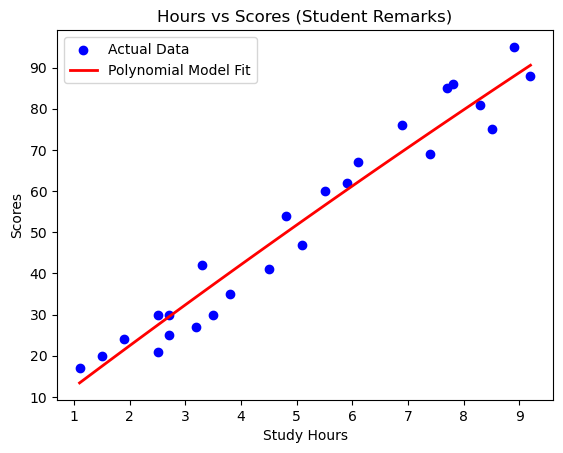

In [44]:
plt.scatter(data['Hours'], data['Scores'], color='blue', label='Actual Data')
X_range = pd.DataFrame({'Hours': np.linspace(data['Hours'].min(), data['Hours'].max(), 100)})
y_range_pred = model_pipeline.predict(X_range)
plt.plot(X_range['Hours'], y_range_pred, color='red', linewidth=2, label='Polynomial Model Fit')
plt.title('Hours vs Scores (Student Remarks)')
plt.xlabel('Study Hours')
plt.ylabel('Scores')
plt.legend()
plt.show()